Loaded 10 chains, 30000 steps, 30 dimensions.


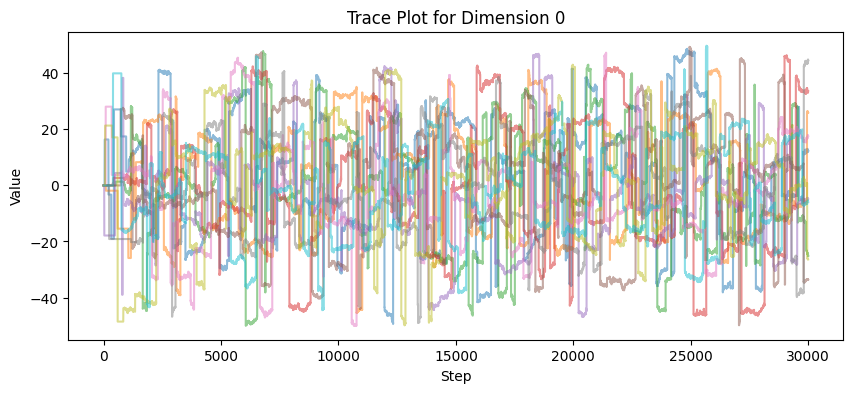

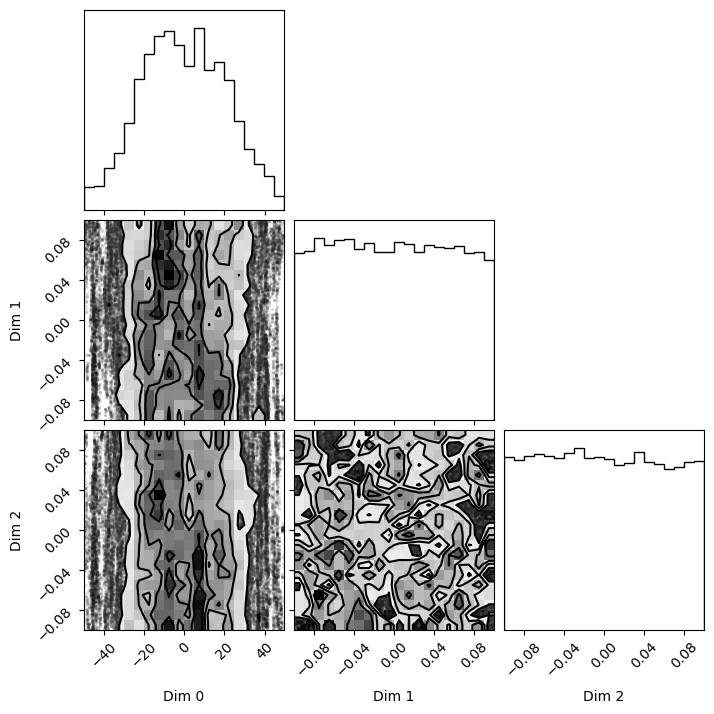

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner  # standard library for MCMC pair plots (pip install corner)

# 1. Load the 3D array in a fraction of a second
samples = np.load("diagnostics/exp2_poly30d_samples.npy")
n_chains, n_steps, d = samples.shape

print(f"Loaded {n_chains} chains, {n_steps} steps, {d} dimensions.")

# 2. Plot a Trace Plot (to visually check mixing and burn-in)
# Plotting the 0th dimension for all chains
plt.figure(figsize=(10, 4))
for c in range(n_chains):
    plt.plot(samples[c, :, 0], alpha=0.5, label=f"Chain {c}")
plt.title("Trace Plot for Dimension 0")
plt.xlabel("Step")
plt.ylabel("Value")
plt.show()

# 3. Create a Corner Plot (to visualize the geometry and correlations)
# Discard the first 10,000 steps as burn-in, and flatten the chains together
burn_in = 10000
flat_samples = samples[:, burn_in:, :].reshape(-1, d)

# Plot just the first 3 dimensions to see the highly skewed Polytope correlations
fig = corner.corner(flat_samples[:, :3], labels=["Dim 0", "Dim 1", "Dim 2"])
plt.show()